<a href="https://colab.research.google.com/github/lgplorea/EjerciciosPython/blob/main/Transformar_de_celsius_a_fahrenheit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Importamos la libreria tensorflow - ayuda a gestionar e implementar procesos de ML
###numpy - para trabajar facilmente con calculos numericos

In [ ]:
import tensorflow as tf
import numpy as np

Ahora declaramos un arreglo de numeros donde colocamos la lista de valores

In [ ]:
celsius = np.array([-40, -20, 0, 9, 18, 20, 35], dtype=float)
fahrenheit = np.array([-40, -4, 32, 48, 64, 68, 95], dtype=float)

Utilizamos Keras , una biblioteca que nos va ayudar a crear mas facil y rapido las capas de redes neuronales

* especificamos solo la capa de salida en una variable y la iniciamos como una capa densa(tiene conexiones desde una neurona hacia todas las neuronas de la siguiente capa) en keras
* de momento solo tenemos una neurona de entrada
* creamos un modelo para darle las capas y trabajar con el, usaremos el Sequential porque es un modelo mas simple
* input_shape nos registra que hay una capa con una sola neurona

In [ ]:
capa = tf.keras.layers.Dense(units=1 , input_shape=[1])
modelo = tf.keras.Sequential([capa])

* el siguiente paso es compilarlo y preparamos el modelo para ser entrenado
* le indicamos como quiero que procese esos datos(optimizer y loss )
* optimizer Adam es un algoritmo para actualizar los pesos de la red de forma iterativa basándose en los datos de entrenamiento.(0.1) es la tasa de aprendizaje
* 'mean_squared_error' una poca cantidad de errores grandes es peor que una cantidad grande de errores pequeños


In [ ]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)

* usamos el metodo fit, le indicamos los datos de entrada y el resultado y le decimos cuantas vueltas queremos que lo intente (1000) y verbose ayuda a evitar la abundancia de verbosidad(imprime muchos errores sin necesidad)

In [ ]:
print("Empezando entrenamiento...")
historial = modelo.fit(celsius, fahrenheit, epochs=1000, verbose=False)
print("Modelo entrenado!")

Empezando entrenamiento...
Modelo entrenado!


Ahora miramos el resultado de la perdida. Como estan de mal los resultados despues de cada vuelta que dio?

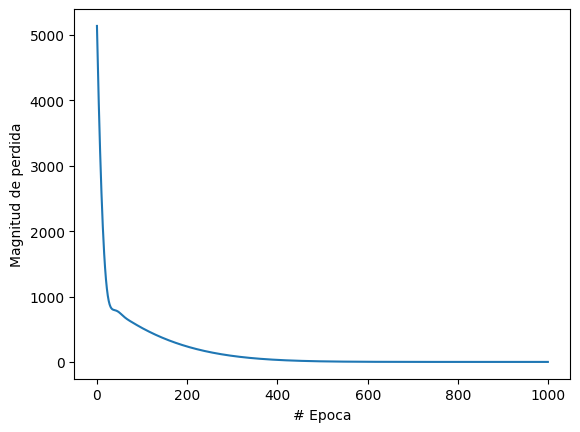

In [ ]:
import matplotlib.pyplot as plt
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de perdida")
plt.plot(historial.history["loss"])

* se puede ver que 1000 vueltas no hacia falta ya que el resultado no cambia mucho despues de 500

In [ ]:
print("Hagamos una prediccion")
resultado = modelo.predict([20.0])
print("El resultado es " + str(resultado) + "fahrenheit!")

Hagamos una prediccion


ValueError: Unrecognized data type: x=[20.0] (of type <class 'list'>)

vamos a ver que datos se asignaron al peso y al sesgo despues del entrenamiento

In [ ]:
print("Variables internas del modelo")
print(capa.get_weights())

Si añadimos mas capas y mas neuronas a la red vamos a ver como actua:  
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([oculta1, oculta2, salida])
 * Al final imprimimos los pesos:
 print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

Que mas se puede predecir?


*  Valor de una casa en base a sus caracteristicas
*  Clasificador de correo spam


*   Deteccion de fraudes
*   Calculo de tiempos





In [ ]:
Hay ramas de esta industria que se dedican a entender, investigar como funciona y porque